# XGBoost for Just-In-Time Bug Prediction

## Objective

The objective of this experiment is to evaluate the performance of
Extreme Gradient Boosting (XGBoost) for predicting defect-inducing
commits in software repositories.

XGBoost is an ensemble learning algorithm based on gradient-boosted
decision trees and is widely recognized for achieving state-of-the-art
performance on structured datasets.

This experiment aims to:

- Train an XGBoost classifier on ApacheJIT software metrics.
- Evaluate its ability to identify bug-inducing commits.
- Compare its performance against Logistic Regression and Random Forest.
- Analyze feature importance and model behavior.

Expected Outcome:

- Improved Recall
- Improved F1 Score
- Improved ROC-AUC

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import joblib

pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/data/processed_data.csv"
)

df.head()

,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp,buggy
0,1063292086,58,0,1,1,1,0.0,1.0,0.0,1.0,10,10.0,6.0,0
1,1063292137,78,0,1,1,1,0.0,0.0,0.0,0.0,21,21.0,1.0,0
2,1063292285,2,3,1,1,1,0.0,2.0,0.0,2.0,11,11.0,7.0,0
3,1063292362,2,0,1,1,1,0.0,2.0,0.0,3.0,12,12.0,8.0,0
4,1063292625,33,0,1,1,1,0.0,1.0,0.0,1.0,13,13.0,9.0,0


In [8]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (106674, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   author_date  106674 non-null  int64  
 1   la           106674 non-null  int64  
 2   ld           106674 non-null  int64  
 3   nf           106674 non-null  int64  
 4   nd           106674 non-null  int64  
 5   ns           106674 non-null  int64  
 6   ent          106674 non-null  float64
 7   ndev         106674 non-null  float64
 8   age          106674 non-null  float64
 9   nuc          106674 non-null  float64
 10  aexp         106674 non-null  int64  
 11  arexp        106674 non-null  float64
 12  asexp        106674 non-null  float64
 13  buggy        106674 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 11.4 MB


In [9]:
features = [
    'la',
    'ld',
    'nf',
    'nd',
    'ns',
    'ent',
    'ndev',
    'age',
    'nuc',
    'aexp',
    'arexp',
    'asexp'
]

target = 'buggy'

In [10]:
df = df.sort_values("author_date")

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 85339
Testing Samples: 21335


In [11]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
buggy
0    60589
1    60589
Name: count, dtype: int64


## Why XGBoost?

XGBoost is capable of capturing complex non-linear relationships
between software metrics and defect-proneness.

Compared to Logistic Regression, XGBoost can model interactions
between features.

Compared to Random Forest, XGBoost builds trees sequentially,
allowing each new tree to correct mistakes made by previous trees.

This often leads to improved predictive performance on structured data.

In [12]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [14]:
accuracy = accuracy_score(y_test, xgb_pred)

precision = precision_score(y_test, xgb_pred)

recall = recall_score(y_test, xgb_pred)

f1 = f1_score(y_test, xgb_pred)

auc = roc_auc_score(y_test, xgb_prob)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

results

,Metric,Value
0,Accuracy,0.721631
1,Precision,0.339450
2,Recall,0.742333
3,F1 Score,0.465869
4,ROC AUC,0.803052


In [22]:
results.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/xgboost_metrics.csv",
    index=False
)

In [15]:
report = classification_report(
    y_test,
    xgb_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.934404,0.717584,0.811765,17846.000000
1,0.339450,0.742333,0.465869,3489.000000
accuracy,0.721631,0.721631,0.721631,0.721631
macro avg,0.636927,0.729958,0.638817,21335.000000
weighted avg,0.837108,0.721631,0.755199,21335.000000


In [23]:
report_df.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/xgboost_classification_report.csv"
)

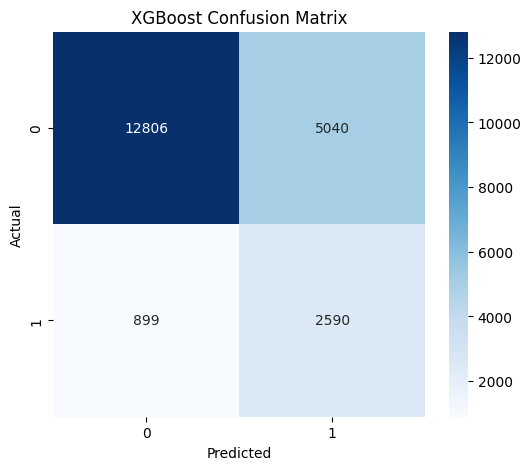

In [21]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/xgboost_matrix.png"
)

plt.show()

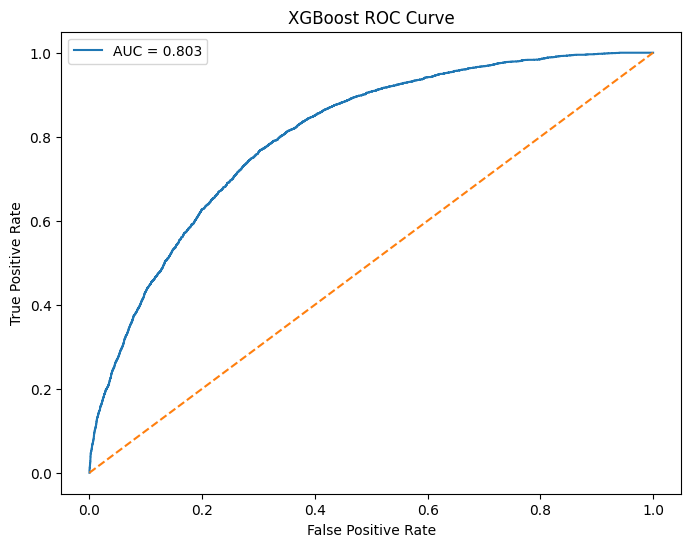

In [20]:
fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/xgboost_roc_curve.png"
)

plt.show()

In [18]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,la,0.287592
2,nf,0.134153
7,age,0.098134
5,ent,0.092430
6,ndev,0.064931
4,ns,0.061019
1,ld,0.057581
8,nuc,0.050080
11,asexp,0.046292
9,aexp,0.039663


In [19]:
importance.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/xgboost_feature_importance.csv",
    index=False
)

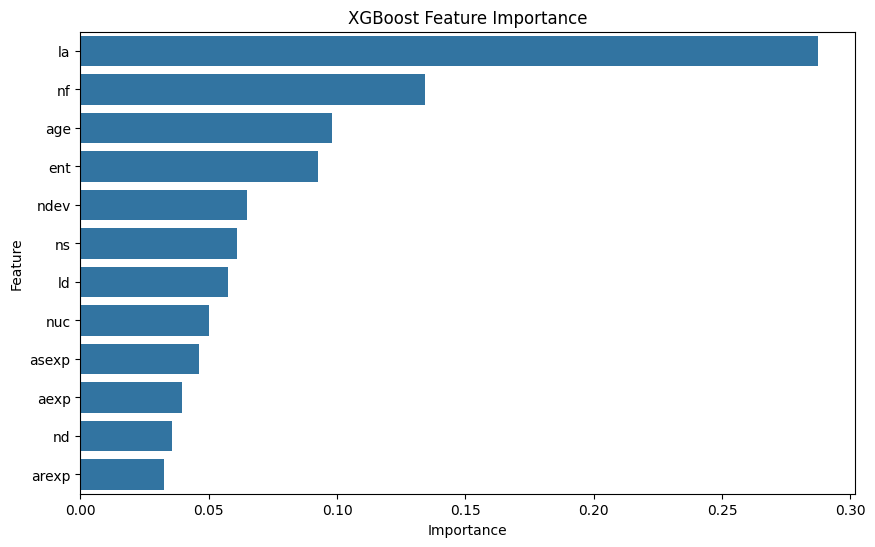

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "XGBoost Feature Importance"
)
plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/xgboost_importance.png"
)

plt.show()

In [28]:
xgb.score(X_train_smote, y_train_smote)

0.8191916024360858

In [30]:
joblib.dump(
    xgb,
    "/content/drive/MyDrive/JIT_bug_prediction/models/xgboost.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.692383,
        0.681837,
        0.721631
    ],
    "Precision": [
        0.304552,
        0.315678,
        0.339450
    ],
    "Recall": [
        0.686443,
        0.809688,
        0.742333
    ],
    "F1 Score": [
        0.421915,
        0.454253,
        0.465869
    ],
    "ROC AUC": [
        0.761170,
        0.808421,
        0.803052
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.692383,0.304552,0.686443,0.421915,0.761170
1,Random Forest,0.681837,0.315678,0.809688,0.454253,0.808421
2,XGBoost,0.721631,0.339450,0.742333,0.465869,0.803052


In [33]:
comparison.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/lr_vs_rf_vs_xg_model_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


# Findings

## XGBoost Performance

| Metric | Value |
|----------|----------|
| Accuracy | 72.16% |
| Precision | 33.95% |
| Recall | 74.23% |
| F1 Score | 46.59% |
| ROC-AUC | 0.8031 |

---

## Interpretation

XGBoost was trained using the same software change metrics
employed in Logistic Regression and Random Forest.

The model achieved strong overall performance across all
evaluation metrics and demonstrated an improved balance between
Precision and Recall.

Compared to the baseline Logistic Regression model, XGBoost
showed substantial improvements in Accuracy, F1 Score, and
ROC-AUC.

---

## Feature Importance Analysis

The most influential predictors identified by XGBoost were:

1. LA (Lines Added)
2. NF (Number of Modified Files)
3. AGE (Average File Age)
4. ENT (Entropy)
5. NDEV (Number of Developers)

These results suggest that large code additions, modifications
across multiple files, and historically unstable files are
important indicators of defect-prone commits.

The findings are consistent with previous software engineering
research on defect prediction.

---

## Comparison with Previous Models

| Metric | Logistic Regression | Random Forest | XGBoost |
|----------|----------|----------|----------|
| Accuracy | 69.24% | 68.18% | 72.16% |
| Precision | 30.46% | 31.57% | 33.95% |
| Recall | 68.64% | 80.97% | 74.23% |
| F1 Score | 42.19% | 45.43% | 46.59% |
| ROC-AUC | 0.7612 | 0.8084 | 0.8031 |

---

## Comparative Analysis

### Compared with Logistic Regression

XGBoost achieved higher Accuracy, Precision, Recall,
F1 Score, and ROC-AUC.

This demonstrates the advantage of ensemble learning methods
for capturing complex relationships among software metrics.

### Compared with Random Forest

Random Forest achieved higher Recall and slightly higher ROC-AUC.

However, XGBoost achieved:

- Higher Accuracy
- Higher Precision
- Higher F1 Score

This indicates that XGBoost provides a better balance between
detecting buggy commits and reducing false positives.

---

## Conclusion

Among the evaluated models, XGBoost demonstrated the strongest
overall predictive performance.

Although Random Forest detected a larger proportion of buggy
commits, XGBoost achieved superior Accuracy, Precision, and
F1 Score while maintaining competitive Recall and ROC-AUC.

Therefore, XGBoost is selected as the current best-performing
model for Just-In-Time Software Bug Prediction on the ApacheJIT
dataset.